In [35]:
import scanpy as sc
import Spectra as spc
import pandas as pd
import numpy as np
from Spectra import Spectra_util as spc_tl
from Spectra import K_est as kst
from Spectra import default_gene_sets
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

### data & annotations preprocessing

In [2]:
annotations = spc.default_gene_sets.load()

In [3]:
# Load your data
adata = sc.read_h5ad('patient_data/anal_pc5_c21_S1.filtered.h5ad')

In [4]:
metadata = pd.read_csv('data/anal_cancer_n21_meta.csv', low_memory=False)
metadata.head()

,Unnamed: 0,samplename,viral_status,cluster_annot,copykat,pathology_status,cluster_annot2,cluster_annot3
0,S1_AAACAAGCAACAGCACACTTTAGG_anal_34449_1_1,S1_Sanal_34449,HPV-_HIV+,T_cells,not.defined,cancer,CD4+Tcells,Tregs
1,S1_AAACAAGCAATTGAGTACTTTAGG_anal_34449_1_1,S1_Sanal_34449,HPV-_HIV+,Myeloid_cells,diploid,cancer,DC_CLEC9A,DC_CLEC9A
2,S1_AAACAAGCACGTAAATACTTTAGG_anal_34449_1_1,S1_Sanal_34449,HPV-_HIV+,Fibroblast_stromal,not.defined,cancer,CD8+Tcells,Fibroblasts/Stromal
3,S1_AAACAAGCACTATCACACTTTAGG_anal_34449_1_1,S1_Sanal_34449,HPV-_HIV+,B_cells,not.defined,cancer,Plasma_XBP1,Plasma_XBP1
4,S1_AAACAAGCAGAATGAAACTTTAGG_anal_34449_1_1,S1_Sanal_34449,HPV-_HIV+,Endothelials,diploid,cancer,Endothelials,Endothelials


In [5]:
metadata = metadata.set_index('Unnamed: 0')
adata.obs['cluster_annot3'] = metadata.loc[adata.obs_names, 'cluster_annot3']

In [6]:
print(adata)
print(adata.obs.head())

AnnData object with n_obs × n_vars = 14133 × 17781
    obs: 'orig.ident', 'cluster_annot3'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
                                           orig.ident       cluster_annot3
S1_AAACAAGCAACAGCACACTTTAGG_anal_34449_1_1         S1                Tregs
S1_AAACAAGCAATTGAGTACTTTAGG_anal_34449_1_1         S1            DC_CLEC9A
S1_AAACAAGCACGTAAATACTTTAGG_anal_34449_1_1         S1  Fibroblasts/Stromal
S1_AAACAAGCACTATCACACTTTAGG_anal_34449_1_1         S1          Plasma_XBP1
S1_AAACAAGCAGAATGAAACTTTAGG_anal_34449_1_1         S1         Endothelials


In [7]:
# Check what cell types are in the default annotations
print("Default annotation keys:", annotations.keys())

Default annotation keys: dict_keys(['B_GC', 'B_memory', 'B_naive', 'CD4_T', 'CD8_T', 'DC', 'ILC3', 'MDC', 'NK', 'Treg', 'gdT', 'mast', 'pDC', 'plasma', 'global'])


In [8]:
# Check what cell types are in the data
print("Cell types in your data:")
print(metadata.cluster_annot3.value_counts())

Cell types in your data:
cluster_annot3
Tumor/Epithelials      171927
Fibroblasts/Stromal     33617
Plasma_XBP1             30276
Endothelials            13279
Mac_C1Q_ZEB2            11520
CD8+Tcells               8802
CD4+Tcells               7574
Tregs                    4528
Bcells_CD19              3986
Mac_C1Q_SPP1             2586
NKcells                  2509
Mon_VCAN                 2489
Mast                     2463
DC_CD207                 2376
CD8+Tcells_Ki67          1868
Neutrophils              1818
DC_LAMP3                 1412
DC_CLEC9A                 838
pDCs                      766
Name: count, dtype: int64


In [9]:
# Map cell types to Spectra's expected cell type labels
annotation_mapping = {
    # T cells
    'CD4+Tcells': 'CD4_T',
    'CD8+Tcells': 'CD8_T',
    'CD8+Tcells_Ki67': 'CD8_T',  # proliferating CD8s still map to CD8_T
    'Tregs': 'Treg',
    'NKcells': 'NK',
    
    # B cells and plasma
    'Bcells_CD19': 'B_naive',  # or B_memory - depends on your data
    'Plasma_XBP1': 'plasma',
    
    # Dendritic cells
    'DC_CD207': 'DC',      # Langerhans/cDC2
    'DC_LAMP3': 'DC',      # mature/migratory DCs
    'DC_CLEC9A': 'DC',     # cDC1
    'pDCs': 'pDC',
    
    # Myeloid
    'Mac_C1Q_ZEB2': 'MDC',  # resident macrophages
    'Mac_C1Q_SPP1': 'MDC',  # inflammatory/SPP1+ macrophages
    'Mon_VCAN': 'MDC',      # classical monocytes
    'Neutrophils': 'MDC',   # if you need to include them
    
    # Other immune
    'Mast': 'mast',
    
    # Non-immune cell types - map to custom labels (not 'global'!)
    'Tumor/Epithelials': 'Epithelial',
    'Fibroblasts/Stromal': 'Fibroblast',
    'Endothelials': 'Endothelial',
}

In [10]:
# Apply the mapping to create the spectra_annot_celltype column
metadata['spectra_annot_celltype'] = metadata['cluster_annot3'].map(annotation_mapping)
# Add to adata
adata.obs['spectra_annot_celltype'] = metadata.loc[adata.obs_names, 'spectra_annot_celltype']

# Check for any unmapped cell types (will be NaN)
print("Unique mapped cell types in adata:")
print(adata.obs['spectra_annot_celltype'].value_counts(dropna=False))

Unique mapped cell types in adata:
spectra_annot_celltype
Epithelial     7299
Fibroblast     1621
plasma         1329
B_naive        1326
CD4_T           624
CD8_T           551
Endothelial     414
MDC             335
Treg            300
DC              136
NK               97
mast             92
pDC               9
Name: count, dtype: int64


In [11]:
# Build annotations_custom with ONLY the cell types present in the data

# Get the unique cell types actually in data (excluding NaN)
adata_celltypes = set(adata.obs['spectra_annot_celltype'].dropna().unique())
print("Cell types in your adata:", adata_celltypes)

# only include 'global' and cell types that exist in the data
annotations_custom = {'global': annotations['global']}
for ct in adata_celltypes:
    if ct in annotations:
        # This cell type has gene sets in the default annotations
        annotations_custom[ct] = annotations[ct]
    else:
        # This cell type (Epithelial, Fibroblast, Endothelial) has no gene sets
        # Add an empty dict so Spectra knows about it
        annotations_custom[ct] = {}

print("\nAnnotations_custom keys:", annotations_custom.keys())

Cell types in your adata: {'Fibroblast', 'CD8_T', 'CD4_T', 'pDC', 'B_naive', 'Endothelial', 'plasma', 'Treg', 'NK', 'Epithelial', 'MDC', 'mast', 'DC'}

Annotations_custom keys: dict_keys(['global', 'Fibroblast', 'CD8_T', 'CD4_T', 'pDC', 'B_naive', 'Endothelial', 'plasma', 'Treg', 'NK', 'Epithelial', 'MDC', 'mast', 'DC'])


In [12]:
# Check if already normalized (values should be small, typically 0-10 range)
print("Max value before normalization:", adata.X.max())

# If max is large, data is raw counts - normalize it
if adata.X.max() > 50:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("Max value after normalization:", adata.X.max())
else:
    print("Data appears to already be normalized")

Max value before normalization: 1552
Max value after normalization: 9.023591


In [13]:
annotations_filtered = spc_tl.check_gene_set_dictionary(
    adata,
    annotations_custom,
    obs_key='spectra_annot_celltype',
    global_key='global'
)
print("Gene set dictionary check passed!")

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.
Gene set dictionary check passed!


In [14]:
# Compute highly variable genes 
sc.pp.highly_variable_genes(adata, n_top_genes=3000)
print(f"Number of highly variable genes: {adata.var['highly_variable'].sum()}")

Number of highly variable genes: 3000


In [15]:
# FIX: Monkey-patch pandas Series to add nonzero() method
# This fixes compatibility between newer pandas and scipy sparse indexing
# The issue is that Spectra's code creates boolean Series that scipy can't handle

if not hasattr(pd.Series, 'nonzero'):
    def _series_nonzero(self):
        return self.to_numpy().nonzero()
    pd.Series.nonzero = _series_nonzero
    print("Applied pandas Series.nonzero() patch")

Applied pandas Series.nonzero() patch


### run & fit spectra model

In [16]:
# Fit the Spectra model
model = spc.est_spectra(
    adata=adata, 
    gene_set_dictionary=annotations_filtered,  # use the filtered annotations
    use_highly_variable=True,
    cell_type_key="spectra_annot_celltype", 
    use_weights=True,
    lam=0.1,  # varies depending on data and gene sets, try between 0.5 and 0.001
    delta=0.001, 
    kappa=None,
    rho=0.001, 
    use_cell_types=True,
    n_top_vals=50,
    label_factors=True, 
    overlap_threshold=0.2,
    clean_gs=True, 
    min_gs_num=3,
    num_epochs=500  # use 10000 for real runs
)

Cell type labels in gene set annotation dictionary and AnnData object are identical
Your gene set annotation dictionary is now correctly formatted.


100%|██████████| 500/500 [10:45<00:00,  1.29s/it]


In [17]:
# View results stored in adata
print("Cell scores shape:", adata.obsm['SPECTRA_cell_scores'].shape)
print("\nFactors stored in adata.uns['SPECTRA_factors']")
print("Markers stored in adata.uns['SPECTRA_markers']")

Cell scores shape: (14133, 191)

Factors stored in adata.uns['SPECTRA_factors']
Markers stored in adata.uns['SPECTRA_markers']


### interpreting first level of spectra outputs

In [18]:
print(adata.uns['SPECTRA_L'])

{'global': 151, 'Fibroblast': 1, 'CD8_T': 7, 'CD4_T': 12, 'pDC': 2, 'B_naive': 1, 'Endothelial': 1, 'plasma': 1, 'Treg': 2, 'NK': 1, 'Epithelial': 1, 'MDC': 6, 'mast': 2, 'DC': 3}


In [ ]:
# === USAGE MATRIX (Cells × Factors) ===
# Get factor labels for nice column names
factor_labels = adata.uns['SPECTRA_overlap'].index.tolist()

usage_matrix = pd.DataFrame(
    adata.obsm['SPECTRA_cell_scores'],
    index=adata.obs_names,
    columns=factor_labels
)
print(f"Usage matrix shape: {usage_matrix.shape}")

# === GEP MATRIX (Factors × Genes) ===
# Get the vocabulary (genes used in model)
vocab_genes = adata.var[adata.var['spectra_vocab']].index.tolist()

gep_matrix = pd.DataFrame(
    adata.uns['SPECTRA_factors'],
    index=factor_labels,
    columns=vocab_genes
)
print(f"GEP matrix shape: {gep_matrix.shape}")

Usage matrix shape: (14133, 191)
GEP matrix shape: (191, 6520)


In [20]:
usage_matrix.head()

,0-X-global-X-all_biotin_metabolism,1-X-global-X-all_DNA-repair,2-X-global-X-leuko_ROS_production,3-X-global-X-all_amino-sugar-nucleotide-sugar_metabolism,4-X-global-X-all_cholesterol-homeostasis,5-X-global-X-all_carnitine-shuttle,6-X-global-X-all_TLR_signaling,7-X-global-X-all_phosphoinositide_signaling,8-X-global-X-all_macroautophagy,9-X-global-X-all_TCA-cycle,...,181-X-MDC-X-181,182-X-MDC-X-182,183-X-NK-X-TNK_cytotoxicity-effectors,184-X-Treg-X-Treg_FoxP3-stabilization,185-X-Treg-X-185,186-X-mast-X-all_multidrug-resistance,187-X-mast-X-187,188-X-pDC-X-p-DC_CpG-TLR9_response,189-X-pDC-X-189,190-X-plasma-X-all_transmembrane-transport-ER
S1_AAACAAGCAACAGCACACTTTAGG_anal_34449_1_1,1.591368e-09,1.744080e-08,8.796550e-11,1.025783e-07,9.158491e-04,3.999212e-10,2.560915e-03,1.926363e-03,1.251294e-09,1.996032e-07,...,0.0,0.0,0.0,0.024476,0.039352,0.0,0.0,0.0,0.0,0.00000
S1_AAACAAGCAATTGAGTACTTTAGG_anal_34449_1_1,2.485473e-08,2.387290e-08,7.215633e-11,8.800211e-08,2.560400e-04,4.565757e-09,8.993199e-09,6.752323e-08,3.805667e-09,2.721203e-07,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000
S1_AAACAAGCACGTAAATACTTTAGG_anal_34449_1_1,1.637756e-10,4.442934e-04,4.670347e-10,5.414966e-08,3.377726e-04,1.856018e-08,4.688173e-08,2.074155e-07,6.766537e-10,3.054226e-03,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000
S1_AAACAAGCACTATCACACTTTAGG_anal_34449_1_1,1.051657e-10,1.743026e-08,4.382522e-11,9.770647e-09,2.514607e-07,3.270519e-07,7.758192e-06,2.974182e-08,1.190233e-08,5.566554e-07,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.02059
S1_AAACAAGCAGAATGAAACTTTAGG_anal_34449_1_1,2.589693e-09,3.344811e-04,9.668130e-10,6.031587e-04,1.668867e-09,1.405269e-09,7.232685e-08,1.361571e-04,1.827676e-09,3.531923e-09,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00000


In [32]:
gep_matrix.head()

,SAMD11,ISG15,TNFRSF18,TNFRSF4,B3GALT6,UBE2J2,TAS1R3,DVL1,MXRA8,NADK,...,RAB41,SLC7A3,ADGRG4,PCDH11Y,AMELY,KLHL40,IL31,ALAS2,ATP1B4,B3GAT2
0-X-global-X-all_biotin_metabolism,1.861280e-19,2.040290e-12,8.238436e-12,4.865969e-17,2.108600e-05,5.651326e-06,2.562564e-18,7.024747e-06,1.631172e-08,1.338429e-16,...,6.646179e-17,5.756090e-19,6.342915e-16,1.107816e-17,6.581213e-17,4.825426e-16,1.211512e-16,2.743484e-19,9.957581e-17,2.410895e-16
1-X-global-X-all_DNA-repair,1.729360e-19,4.876477e-14,5.659255e-15,3.347290e-17,3.768825e-14,5.814397e-14,2.300382e-18,5.177831e-16,2.853950e-14,1.294564e-18,...,4.095826e-17,7.608552e-19,6.812812e-16,8.627877e-18,5.176878e-17,1.713704e-16,9.434927e-17,1.735648e-19,1.831136e-17,1.074744e-17
2-X-global-X-leuko_ROS_production,2.297006e-19,1.769544e-15,5.877056e-11,4.039328e-17,4.641791e-08,2.578888e-18,3.050419e-18,2.335125e-21,1.120797e-18,3.155866e-21,...,3.082306e-17,2.421287e-19,3.223225e-16,8.078225e-18,4.920731e-17,1.219801e-16,9.833252e-17,2.472534e-20,4.019610e-19,9.033175e-19
3-X-global-X-all_amino-sugar-nucleotide-sugar_metabolism,1.543573e-19,8.992630e-14,6.952480e-12,3.155314e-17,1.339101e-13,1.410925e-10,2.771670e-18,2.863767e-11,4.284679e-14,4.677423e-17,...,3.394575e-17,9.795510e-19,3.332894e-16,9.422989e-18,5.411029e-17,1.485191e-15,1.298680e-16,1.824921e-19,1.081762e-16,1.149403e-16
4-X-global-X-all_cholesterol-homeostasis,2.458225e-19,8.986372e-14,5.093866e-15,8.507592e-17,1.650829e-15,3.446691e-14,4.726547e-18,4.989951e-15,9.878576e-15,9.932098e-18,...,9.588512e-17,5.137943e-19,8.156326e-16,1.039126e-17,6.347042e-17,6.264297e-16,5.928047e-17,1.007487e-19,1.875040e-16,7.855101e-17


In [33]:
print(adata.uns['SPECTRA_markers'][0])  # top genes for factor x

['HLCS' 'SLC5A6' 'BTD' 'SLC19A3' 'AKR7A2' 'DDX10' 'PIDD1' 'CETN2' 'BMPR1A'
 'COX5B' 'DFFA' 'BID' 'PSMG1' 'MPC2' 'COL1A2' 'PLOD2' 'DESI1' 'UROS'
 'PNO1' 'SUPT4H1' 'ETFDH' 'GNG12' 'AP2A2' 'SKP2' 'TUBGCP5' 'HSPE1' 'ALG8'
 'NTHL1' 'PIK3CA' 'SEMA3B' 'XPOT' 'SASS6' 'XRCC6' 'FOXRED2' 'EIF4E' 'LSM1'
 'TIMM9' 'NDUFB1' 'BPHL' 'COX7B' 'HSPA4L' 'CYCS' 'TOMM40' 'RSL1D1' 'PSMB3'
 'ATP5F1C' 'ACVR1' 'ACSM3' 'RNF14' 'HSPBP1']


### splitting global factors into cell type specific factors

1) Extract global factors and create cell-type factor profiles

In [36]:
# Get the number of global factors
n_global_factors = adata.uns['SPECTRA_L']['global']
print(f"Number of global factors: {n_global_factors}")

# Extract cell scores for global factors only (first n_global factors)
cell_scores_global = adata.obsm['SPECTRA_cell_scores'][:, :n_global_factors]

# Get factor labels from the overlap index
factor_labels = adata.uns['SPECTRA_overlap'].index[:n_global_factors].tolist()

# Create a DataFrame with cell scores
cell_scores_df = pd.DataFrame(
    cell_scores_global,
    index=adata.obs_names,
    columns=factor_labels
)

# Add cell type annotation
cell_scores_df['cell_type'] = adata.obs['spectra_annot_celltype'].values

# Remove any cells with missing cell type
cell_scores_df = cell_scores_df.dropna(subset=['cell_type'])

print(f"Cell scores shape: {cell_scores_df.shape}")
print(f"Cell types: {cell_scores_df['cell_type'].unique()}")

Number of global factors: 151
Cell scores shape: (14133, 152)
Cell types: ['Treg', 'DC', 'Fibroblast', 'plasma', 'Endothelial', ..., 'NK', 'CD4_T', 'MDC', 'mast', 'pDC']
Length: 13
Categories (13, object): ['B_naive', 'CD4_T', 'CD8_T', 'DC', ..., 'Treg', 'mast', 'pDC', 'plasma']


2. Calculate mean factor activity per cell type

In [ ]:
# Group by cell type and calculate mean
celltype_factor_mean = cell_scores_df.groupby('cell_type').mean()

# Also calculate median (more robust to outliers)
celltype_factor_median = cell_scores_df.groupby('cell_type').median()

# Calculate standard deviation
celltype_factor_std = cell_scores_df.groupby('cell_type').std()
# Calculate coefficient of variation (std/mean) - measures relative variability
celltype_factor_cv = celltype_factor_std / (celltype_factor_mean + 1e-10)

print(f"\nCell type × Factor matrix shape: {celltype_factor_mean.shape}")


Cell type × Factor matrix shape: (13, 151)


/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_11019/2267444590.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_factor_mean = cell_scores_df.groupby('cell_type').mean()
/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_11019/2267444590.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_factor_median = cell_scores_df.groupby('cell_type').median()
/var/folders/bw/grhyggnj06ncywf0093kz3ch0000gn/T/ipykernel_11019/2267444590.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to r

,0-X-global-X-all_biotin_metabolism,1-X-global-X-all_DNA-repair,2-X-global-X-leuko_ROS_production,3-X-global-X-all_amino-sugar-nucleotide-sugar_metabolism,4-X-global-X-all_cholesterol-homeostasis,5-X-global-X-all_carnitine-shuttle,6-X-global-X-all_TLR_signaling,7-X-global-X-all_phosphoinositide_signaling,8-X-global-X-all_macroautophagy,9-X-global-X-all_TCA-cycle,...,141-X-global-X-all_NOTCH_signaling,142-X-global-X-all_galactose_metabolism,143-X-global-X-all_MYC_targets,144-X-global-X-all_GLU_metabolism,145-X-global-X-all_fatty-acid_synthesis,146-X-global-X-all_glycolysis,147-X-global-X-all_glutathione_metabolism,148-X-global-X-148,149-X-global-X-all_autophagy-chaperone-mediated,150-X-global-X-150
cell_type,,,,,,,,,,,,,,,,,,,,,
B_naive,0.000342,0.000130,1.461723e-09,0.000211,0.000200,0.000484,0.000234,0.000337,0.000083,0.000868,...,0.000234,0.000317,0.000692,0.000081,0.000159,0.000114,0.000161,0.001010,0.000719,0.006758
CD4_T,0.000241,0.000156,6.688899e-07,0.000197,0.000159,0.000505,0.000155,0.000348,0.000063,0.000698,...,0.000142,0.000155,0.000529,0.000089,0.000139,0.000078,0.000171,0.000943,0.000751,0.002487
CD8_T,0.000200,0.000156,1.000873e-06,0.000187,0.000183,0.000376,0.000134,0.000328,0.000064,0.000913,...,0.000142,0.000460,0.000536,0.000103,0.000150,0.000085,0.000167,0.001187,0.000663,0.003330
DC,0.000401,0.000104,4.925609e-06,0.000175,0.000217,0.000264,0.000283,0.000321,0.000073,0.001004,...,0.000284,0.000323,0.000770,0.000089,0.000166,0.000122,0.000185,0.001383,0.000861,0.003490
Endothelial,0.000369,0.000151,3.766628e-05,0.000251,0.000211,0.000211,0.000234,0.000419,0.000096,0.000904,...,0.000311,0.000677,0.000650,0.000082,0.000204,0.000121,0.000208,0.001995,0.000810,0.006080


3. Z-score normalize across cell types for better comparison

In [ ]:
# Z-score normalize each factor across cell types
# This shows which cell types have above/below average activity for each factor
celltype_factor_zscore = celltype_factor_median.apply(stats.zscore, axis=0)
# Replace any NaN (from constant columns) with 0
celltype_factor_zscore = celltype_factor_zscore.fillna(0)

4. Identify cell-type specific factors

In [44]:
def identify_specific_factors(zscore_df, threshold=1.5):
    """
    Identify factors that are specific to one or few cell types.
    
    A factor is considered cell-type specific if:
    - It has z-score > threshold in only 1-2 cell types
    - OR it has z-score < -threshold in most cell types except 1-2
    
    Returns a DataFrame with specificity annotations.
    """
    results = []
    
    for factor in zscore_df.columns:
        scores = zscore_df[factor]
        
        # Cell types with high activity
        high_activity = scores[scores > threshold].index.tolist()
        
        # Cell types with low activity
        low_activity = scores[scores < -threshold].index.tolist()
        
        # Determine specificity
        n_celltypes = len(zscore_df)
        n_high = len(high_activity)
        n_low = len(low_activity)
        
        if n_high == 1:
            specificity = 'highly_specific'
            specific_to = high_activity
        elif n_high == 2:
            specificity = 'moderately_specific'
            specific_to = high_activity
        elif n_high >= n_celltypes - 2 or n_low <= 1:
            specificity = 'broadly_expressed'
            specific_to = []
        else:
            specificity = 'subset_specific'
            specific_to = high_activity
        
        # Get the max z-score and which cell type
        max_zscore = scores.max()
        max_celltype = scores.idxmax()
        
        results.append({
            'factor': factor,
            'specificity': specificity,
            'specific_to': specific_to,
            'n_high_celltypes': n_high,
            'max_zscore': max_zscore,
            'max_celltype': max_celltype,
            'high_celltypes': high_activity,
            'low_celltypes': low_activity
        })
    
    return pd.DataFrame(results)


In [46]:
# Identify specific factors
factor_specificity = identify_specific_factors(celltype_factor_zscore, threshold=1.5)

print("\n" + "="*60)
print("FACTOR SPECIFICITY SUMMARY")
print("="*60)
print(factor_specificity['specificity'].value_counts())

#  highly specific factors
highly_specific = factor_specificity[factor_specificity['specificity'] == 'highly_specific']


FACTOR SPECIFICITY SUMMARY
specificity
highly_specific        111
moderately_specific     31
broadly_expressed        7
subset_specific          2
Name: count, dtype: int64


In [ ]:
# Clean up factor names for easier reading
def clean_factor_name(name):
    """Extract just the gene set name from the full factor label."""
    parts = name.split('-X-')
    if len(parts) >= 3:
        return parts[2]  # The gene set name
    return name

factor_specificity['factor_short'] = factor_specificity['factor'].apply(clean_factor_name)

# Create a cell type × factor heatmap-ready matrix
# with factor specificity annotations
celltype_factor_annotated = celltype_factor_zscore.copy()

### visualizations

1. Heatmap of cell type × factor activity

**Color Interpretation:**
- **Deep RED** (positive z-score): Factor is highly active in that cell type relative to others
- **Deep BLUE** (negative z-score): Factor is suppressed in that cell type relative to others
- **WHITE/pale** (z ≈ 0): Average activity across cell types

**Pattern Recognition:**
- **Horizontal patterns (rows)**: A row with one red cell and many blue cells indicates a factor highly specific to a single cell type
- **Vertical patterns (columns)**: Columns predominantly one color indicate cell types with globally elevated or suppressed factor activity
- **Original ordering**: Preserves factor indexing, which may group biologically related pathways if your annotations are organized

**Biological Insights:**
- Identify which pathways are enriched in specific cell types
- Spot factors that distinguish tumor-infiltrating immune cells from stromal components
- See if certain metabolic or signaling pathways dominate particular cell populations

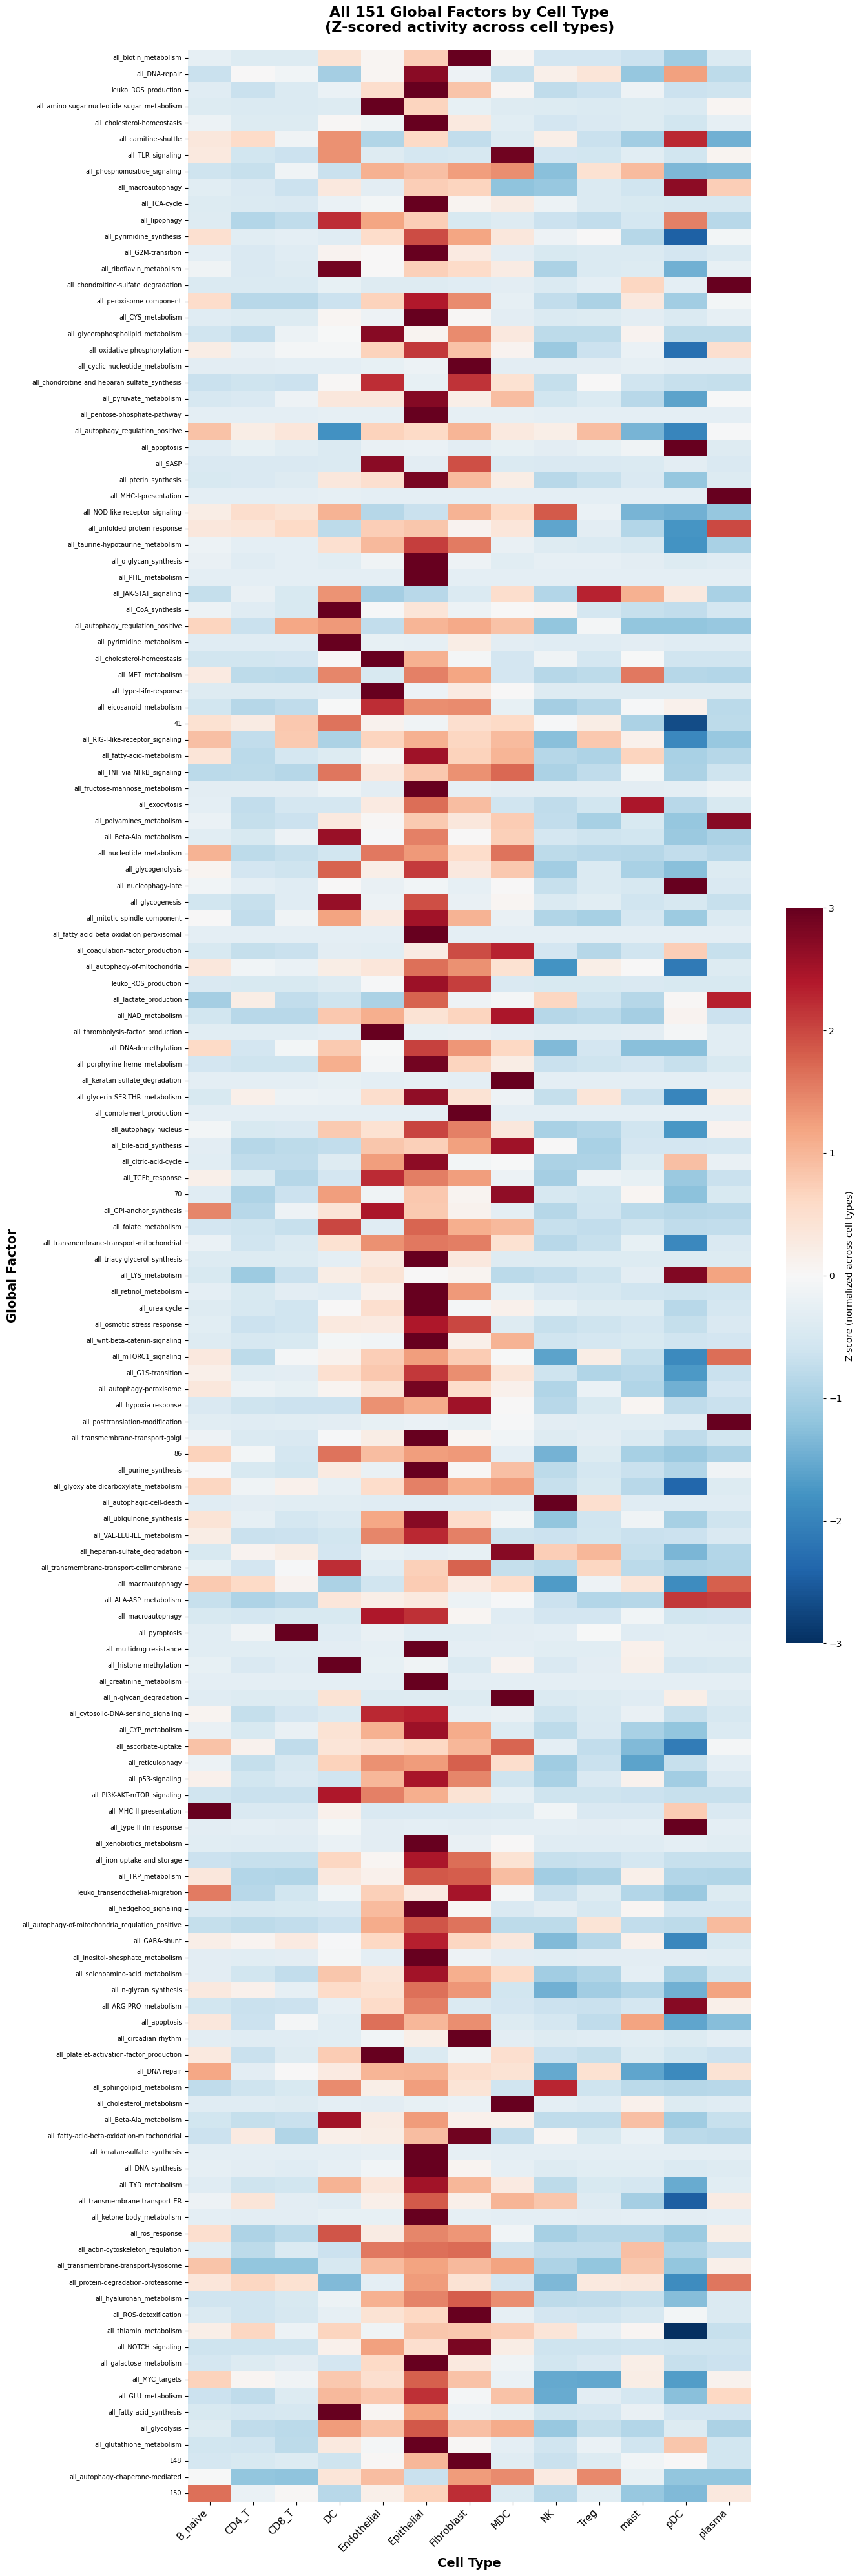

In [54]:
# transpose so factors are rows, cell types are columns
heatmap_data_full = celltype_factor_zscore.T.copy()

# clean up factor names for display
heatmap_data_full.index = [clean_factor_name(f) for f in heatmap_data_full.index]

# Calculate figure height based on number of factors (~0.25 inches per factor)
n_factors = len(heatmap_data_full)
fig_height = max(40, n_factors * 0.25)

fig, ax = plt.subplots(figsize=(14, fig_height))
hm = sns.heatmap(
    heatmap_data_full,
    cmap='RdBu_r',
    center=0,
    vmin=-3,
    vmax=3,
    xticklabels=True,
    yticklabels=True,
    ax=ax,
    cbar_kws={'label': 'Z-score (normalized across cell types)', 'shrink': 0.3}
)
ax.set_xlabel('Cell Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Global Factor', fontsize=14, fontweight='bold')
ax.set_title('All 151 Global Factors by Cell Type\n(Z-scored activity across cell types)', 
             fontsize=16, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=7)  # Small but readable for 151 factors
plt.tight_layout()
plt.show()

2. Clustered heatmap with dendrograms

*Row dendrogram (left side - factors):*
- Groups factors with similar cell-type activation profiles
- **Tight clusters** = factors that behave similarly across all cell types (co-regulated pathways or redundant gene programs)
- Factors in the same cluster may represent functionally related biological processes

*Column dendrogram (top - cell types):*
- Groups cell types with similar factor profiles

**Block Structure:**
- Rectangular regions of similar color = **modules** of factors co-active in subsets of cell types
- These modules often represent lineage-specific biological processes

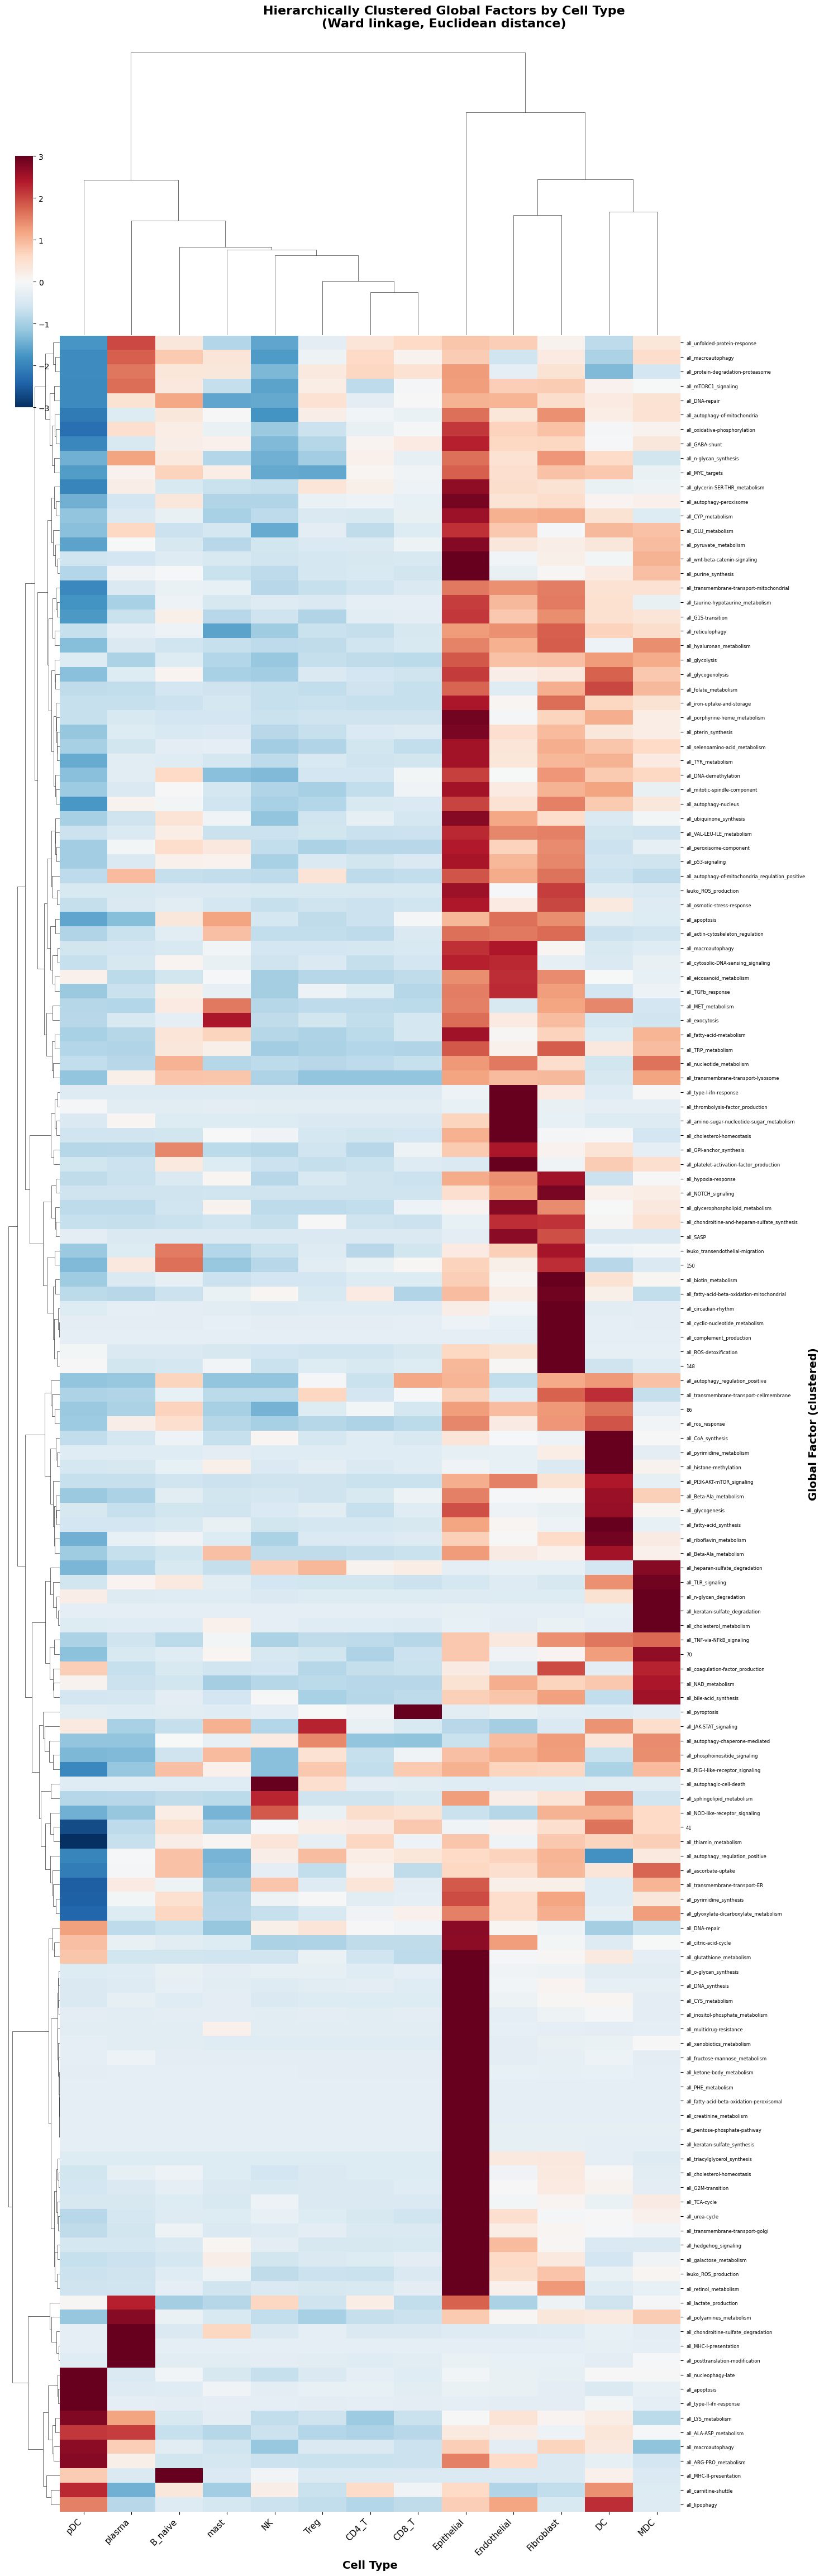

In [55]:
fig_height_cluster = max(45, n_factors * 0.28)

# clustermap with all factors
g = sns.clustermap(
    heatmap_data_full,
    cmap='RdBu_r',
    center=0,
    vmin=-3,
    vmax=3,
    figsize=(16, fig_height_cluster),
    dendrogram_ratio=(0.08, 0.12),  # (row_dendrogram, col_dendrogram) proportions
    cbar_pos=(0.02, 0.85, 0.02, 0.1),  # Colorbar position
    xticklabels=True,
    yticklabels=True,
    method='ward',  # Clustering method - ward minimizes variance
    metric='euclidean',  # Distance metric
    row_cluster=True,  # Cluster factors
    col_cluster=True   # Cluster cell types
)
g.ax_heatmap.set_xlabel('Cell Type', fontsize=14, fontweight='bold')
g.ax_heatmap.set_ylabel('Global Factor (clustered)', fontsize=14, fontweight='bold')
g.ax_heatmap.tick_params(axis='y', labelsize=6)  # Smaller for clustered view
g.ax_heatmap.tick_params(axis='x', labelsize=11, rotation=45)
plt.setp(g.ax_heatmap.get_xticklabels(), ha='right', rotation=45)
g.fig.suptitle('Hierarchically Clustered Global Factors by Cell Type\n(Ward linkage, Euclidean distance)', 
               fontsize=16, fontweight='bold', y=1.01)
plt.show()

3. summary stats

**Panel A (Histogram):**
- Shows how many factors are highly cell-type specific vs broadly expressed
- Factors with max z-score > 1.5 are considered "specific" to at least one cell type
- A right-skewed distribution suggests many factors have strong cell-type preferences

**Panel B (Bar chart):**
- Shows which cell types have the most specific factors associated with them
- Cell types with more specific factors may have more unique transcriptional programs
- In cancer, this might highlight cells with distinct functional states

**Panel C (Threshold matrix):**
- Shows how specificity counts change at different thresholds
- Helps you decide on an appropriate threshold for your downstream analysis
- Cell types that maintain high counts at z > 3.0 have very strongly distinguishing factors

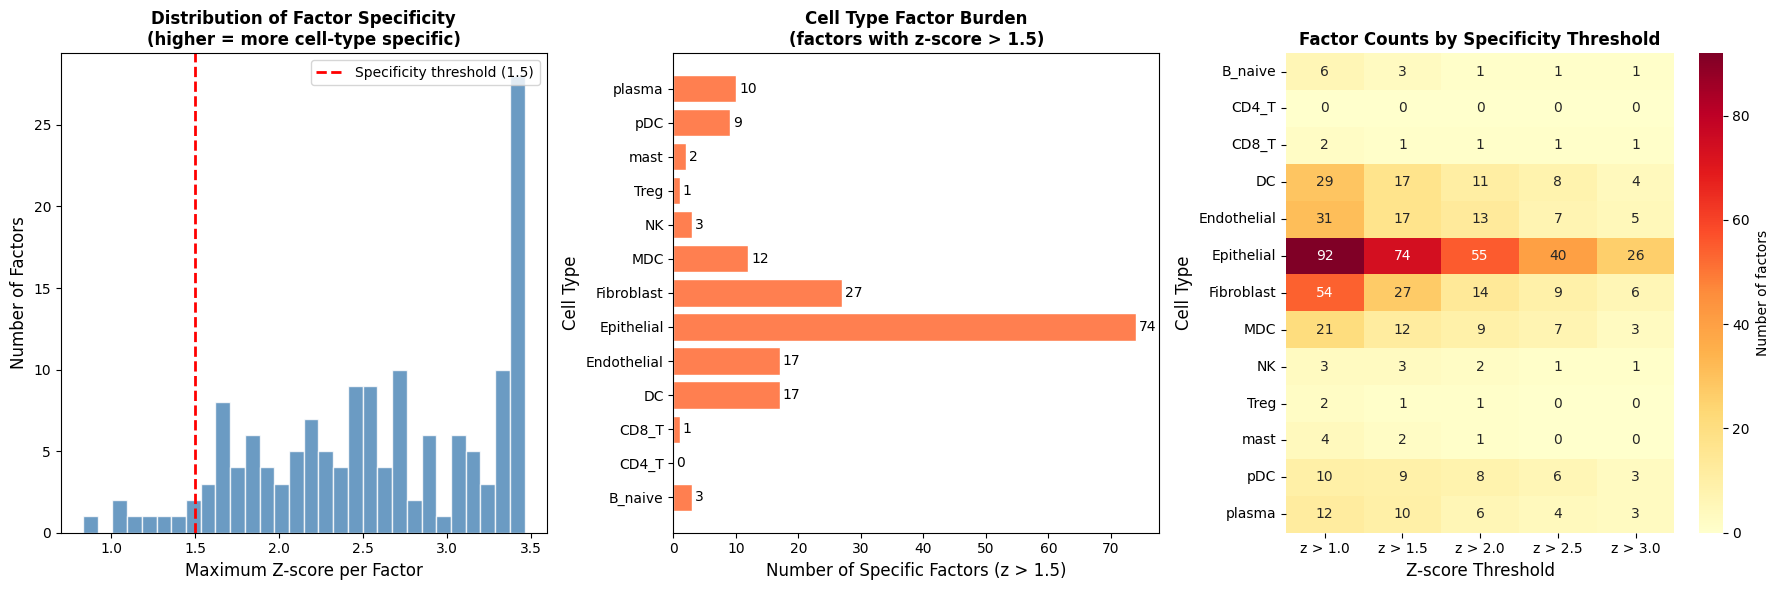

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel A: Distribution of max z-scores per factor
max_zscores = celltype_factor_zscore.max(axis=0)
axes[0].hist(max_zscores, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=1.5, color='red', linestyle='--', linewidth=2, label='Specificity threshold (1.5)')
axes[0].set_xlabel('Maximum Z-score per Factor', fontsize=12)
axes[0].set_ylabel('Number of Factors', fontsize=12)
axes[0].set_title('Distribution of Factor Specificity\n(higher = more cell-type specific)', 
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Panel B: Number of specific factors per cell type
n_specific = (celltype_factor_zscore > 1.5).sum(axis=1)
bars = axes[1].barh(n_specific.index, n_specific.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Specific Factors (z > 1.5)', fontsize=12)
axes[1].set_ylabel('Cell Type', fontsize=12)
axes[1].set_title('Cell Type Factor Burden\n(factors with z-score > 1.5)', 
                  fontsize=12, fontweight='bold')
for bar, val in zip(bars, n_specific.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), 
                 va='center', fontsize=10)

# Panel C: Heatmap of factor specificity counts at different thresholds
specificity_matrix = pd.DataFrame(index=celltype_factor_zscore.index)
for threshold in [1.0, 1.5, 2.0, 2.5, 3.0]:
    specificity_matrix[f'z > {threshold}'] = (celltype_factor_zscore > threshold).sum(axis=1)

sns.heatmap(specificity_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=axes[2],
            cbar_kws={'label': 'Number of factors'})
axes[2].set_xlabel('Z-score Threshold', fontsize=12)
axes[2].set_ylabel('Cell Type', fontsize=12)
axes[2].set_title('Factor Counts by Specificity Threshold', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

8. Identify factors specific to each cell type

In [51]:
celltype_top_factors = {}

for ct in celltype_factor_zscore.index:
    # Get factors ranked by z-score for this cell type
    ct_scores = celltype_factor_zscore.loc[ct].sort_values(ascending=False)
    
    # Top 5 factors for this cell type
    top_factors = ct_scores.head(5)
    
    celltype_top_factors[ct] = top_factors
    
    print(f"\n{ct}:")
    for factor, zscore in top_factors.items():
        factor_short = clean_factor_name(factor)
        print(f"  {factor_short[:50]}: z={zscore:.2f}")



B_naive:
  all_MHC-II-presentation: z=3.25
  150: z=1.66
  leuko_transendothelial-migration: z=1.55
  all_GPI-anchor_synthesis: z=1.46
  all_DNA-repair: z=1.17

CD4_T:
  all_protein-degradation-proteasome: z=0.64
  all_thiamin_metabolism: z=0.64
  all_macroautophagy: z=0.60
  all_carnitine-shuttle: z=0.58
  all_NOD-like-receptor_signaling: z=0.52

CD8_T:
  all_pyroptosis: z=3.45
  all_autophagy_regulation_positive: z=1.16
  41: z=0.80
  all_RIG-I-like-receptor_signaling: z=0.79
  all_unfolded-protein-response: z=0.59

DC:
  all_pyrimidine_metabolism: z=3.42
  all_histone-methylation: z=3.38
  all_CoA_synthesis: z=3.29
  all_fatty-acid_synthesis: z=3.08
  all_riboflavin_metabolism: z=2.89

Endothelial:
  all_thrombolysis-factor_production: z=3.45
  all_type-I-ifn-response: z=3.40
  all_amino-sugar-nucleotide-sugar_metabolism: z=3.30
  all_cholesterol-homeostasis: z=3.09
  all_platelet-activation-factor_production: z=3.07

Epithelial:
  all_fatty-acid-beta-oxidation-peroxisomal: z=3.46
